# Missouri Care Gap Market Analysis

## Objective

This project analyzes county-level social determinants of health (SDOH),
health burden, and healthcare resource availability across Missouri to
identify areas with the largest potential care coordination gaps.

The analysis integrates CDC PLACES, HRSA FQHC, and Census ACS data
to quantify vulnerability and resource distribution across Missouri counties.

## Step 1 — CDC PLACES Health Burden Data

This section loads and processes county-level CDC PLACES indicators
including uninsured burden, poor mental health prevalence, diabetes,
hypertension, obesity, and COPD prevalence.

In [67]:
import pandas as pd
from pathlib import Path

# Set folders
DATA_RAW = Path("data/raw")
DATA_PROCESSED = Path("data/processed")

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# Load CDC PLACES dataset
places = pd.read_csv("places.csv", low_memory=False)

# Keep Missouri only
mo_places = places[places["StateAbbr"] == "MO"].copy()

print("Missouri rows:", mo_places.shape)
mo_places.head()

Missouri rows: (9200, 22)


,Year,StateAbbr,StateDesc,LocationName,DataSource,Category,Measure,Data_Value_Unit,Data_Value_Type,Data_Value,...,Low_Confidence_Limit,High_Confidence_Limit,TotalPopulation,TotalPop18plus,LocationID,CategoryID,MeasureId,DataValueTypeID,Short_Question_Text,Geolocation
107875,2022,MO,Missouri,Cape Girardeau,BRFSS,Prevention,Mammography use among women aged 50-74 years,%,Crude prevalence,75.0,...,67.3,81.6,"82,984","65,388",29031,PREVENT,MAMMOUSE,CrdPrv,Mammography,POINT (-89.6846025463066 37.3842882926918)
107876,2022,MO,Missouri,Saline,BRFSS,Prevention,Colorectal cancer screening among adults aged ...,%,Crude prevalence,60.5,...,55.3,65.5,"23,049","18,077",29195,PREVENT,COLON_SCREEN,CrdPrv,Colorectal Cancer Screening,POINT (-93.2018268315702 39.1367890617691)
107886,2023,MO,Missouri,Lincoln,BRFSS,Prevention,Current lack of health insurance among adults ...,%,Crude prevalence,8.7,...,6.6,11.0,"64,699","48,548",29113,PREVENT,ACCESS2,CrdPrv,Health Insurance,POINT (-90.9596887907671 39.0579189378676)
107887,2023,MO,Missouri,Madison,BRFSS,Health Outcomes,Chronic obstructive pulmonary disease among ad...,%,Age-adjusted prevalence,8.1,...,6.8,9.4,"12,698","9,847",29123,HLTHOUT,COPD,AgeAdjPrv,COPD,POINT (-90.3449925444979 37.4780468766804)
107888,2023,MO,Missouri,Phelps,BRFSS,Health-Related Social Needs,Utility services shut-off threat in the past 1...,%,Crude prevalence,8.5,...,7.0,10.0,"45,284","35,710",29161,SOCLNEED,SHUTUTILITY,CrdPrv,Utility Services Threat,POINT (-91.7923257288082 37.8770153181716)


In [5]:
needed_measures = [
    "ACCESS2",   # Current lack of health insurance
    "MHLTH",     # Poor mental health
    "DIABETES",  # Diabetes prevalence
    "BPHIGH",    # High blood pressure
    "OBESITY",   # Obesity prevalence
    "COPD"       # COPD prevalence
]

mo_filtered = mo_places[
    mo_places["MeasureId"].isin(needed_measures)
].copy()

print(mo_filtered.shape)
mo_filtered[["LocationName", "Measure", "MeasureId", "Data_Value"]].head(20)

(1380, 22)


,LocationName,Measure,MeasureId,Data_Value
107886,Lincoln,Current lack of health insurance among adults ...,ACCESS2,8.7
107887,Madison,Chronic obstructive pulmonary disease among ad...,COPD,8.1
107891,Worth,Obesity among adults,OBESITY,40.2
107905,McDonald,Frequent mental distress among adults,MHLTH,21.4
107917,Mercer,Frequent mental distress among adults,MHLTH,18.0
107924,Saline,Diagnosed diabetes among adults,DIABETES,11.2
107937,Shannon,Chronic obstructive pulmonary disease among ad...,COPD,9.0
107941,Putnam,Frequent mental distress among adults,MHLTH,19.3
107950,Barton,Diagnosed diabetes among adults,DIABETES,15.2
107969,Lewis,Frequent mental distress among adults,MHLTH,19.1


In [6]:
county_health = mo_filtered.pivot_table(
    index=["LocationName", "LocationID", "TotalPopulation"],
    columns="MeasureId",
    values="Data_Value",
    aggfunc="first"
).reset_index()

county_health.head()

MeasureId,LocationName,LocationID,TotalPopulation,ACCESS2,BPHIGH,COPD,DIABETES,MHLTH,OBESITY
0,Adair,29001,"25,122",8.2,30.3,7.9,10.0,19.0,34.7
1,Andrew,29003,"18,127",7.7,38.3,6.5,11.6,18.2,35.8
2,Atchison,29005,"5,107",9.5,34.7,10.9,10.9,16.9,41.6
3,Audrain,29007,"24,394",10.4,39.6,10.7,11.6,19.3,39.9
4,Barry,29009,"35,265",12.8,34.0,11.3,11.6,20.1,37.7


In [7]:
county_health = county_health.rename(columns={
    "LocationName": "county_name",
    "LocationID": "county_fips",
    "TotalPopulation": "population",
    "ACCESS2": "uninsured_rate",
    "MHLTH": "poor_mental_health",
    "DIABETES": "diabetes_rate",
    "BPHIGH": "high_bp_rate",
    "OBESITY": "obesity_rate",
    "COPD": "copd_rate"
})

county_health.head()

MeasureId,county_name,county_fips,population,uninsured_rate,high_bp_rate,copd_rate,diabetes_rate,poor_mental_health,obesity_rate
0,Adair,29001,"25,122",8.2,30.3,7.9,10.0,19.0,34.7
1,Andrew,29003,"18,127",7.7,38.3,6.5,11.6,18.2,35.8
2,Atchison,29005,"5,107",9.5,34.7,10.9,10.9,16.9,41.6
3,Audrain,29007,"24,394",10.4,39.6,10.7,11.6,19.3,39.9
4,Barry,29009,"35,265",12.8,34.0,11.3,11.6,20.1,37.7


In [8]:
county_health.shape

(115, 9)

In [9]:
county_health.to_csv(
    "data/processed/missouri_county_health_metrics.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [10]:
county_health.sort_values("uninsured_rate", ascending=False).head(10)

MeasureId,county_name,county_fips,population,uninsured_rate,high_bp_rate,copd_rate,diabetes_rate,poor_mental_health,obesity_rate
63,McDonald,29119,"23,903",13.9,41.0,10.3,13.5,21.4,42.7
66,Mississippi,29133,"11,822",13.2,40.0,10.5,14.1,21.2,47.7
105,Sullivan,29211,"5,797",13.2,41.1,10.3,11.9,17.7,40.4
77,Pemiscot,29155,"14,613",13.1,40.1,11.3,17.9,20.5,44.9
34,Dunklin,29069,"27,032",12.9,38.7,12.3,16.0,20.0,46.2
4,Barry,29009,"35,265",12.8,34.0,11.3,11.6,20.1,37.7
76,Ozark,29153,"8,970",12.4,47.7,10.8,12.5,22.0,42.5
114,Wright,29229,"19,403",12.1,35.6,10.4,12.5,21.6,42.1
42,Hickory,29085,"8,718",11.9,37.1,11.1,19.7,22.1,43.0
107,Texas,29215,"25,619",11.8,43.8,10.0,12.7,19.1,42.2


## Step 2 — HRSA FQHC Resource Data

This section integrates HRSA Federally Qualified Health Center (FQHC)
site data to estimate healthcare resource availability across Missouri counties.

In [11]:
import pandas as pd

# Load HRSA health center sites
fqhc = pd.read_csv("hrsa_health_center_sites.csv", low_memory=False)

print(fqhc.shape)
fqhc.head()

(18905, 56)


,Health Center Type,Health Center Number,BHCMIS Organization Identification Number,BPHC Assigned Number,Site Name,Site Address,Site City,Site State Abbreviation,Site Postal Code,Site Telephone Number,...,State Name,State FIPS and Congressional District Number Code,Congressional District Number,Congressional District Name,Congressional District Code,U.S. Congressional Representative Name,Name of U.S. Senator Number One,Name of U.S. Senator Number Two,Data Warehouse Record Create Date,Unnamed: 55
0,Federally Qualified Health Center (FQHC),H80CS00189,051570,BPS-H80-041310,YWCA Cincinnati,3565 Van Antwerp Pl,Cincinnati,OH,45229-2631,513-286-7899,...,Ohio,3901,1,Ohio District 01,OH-01,Greg Landsman,Bernie Moreno,Jon Husted,05/05/2026,NaN
1,Federally Qualified Health Center (FQHC),H80CS00046,090830,BPS-H80-000108,GOOD SAMARITAN SHELTER,401 W Morrison Ave,Santa Maria,CA,93458-6124,805-346-8185,...,California,0624,24,California District 24,CA-24,Salud O. Carbajal,Alex Padilla,Adam B. Schiff,05/05/2026,NaN
2,Federally Qualified Health Center (FQHC),H80CS00587,097880,BPS-H80-014051,Mary Isaak Homeless Shelter Clinic,900 Hopper St,Petaluma,CA,94952-3388,707-559-7500,...,California,0602,2,California District 02,CA-02,Jared Huffman,Alex Padilla,Adam B. Schiff,05/05/2026,NaN
3,Federally Qualified Health Center (FQHC),H80CS00807,090990,BPS-H80-013815,Kamaile Olakino Maika'i Health Center,85-180 Ala Akau St,Waianae,HI,96792-2375,808-697-3496,...,Hawaii,1502,2,Hawaii District 02,HI-02,Jill N. Tokuda,Brian Schatz,Mazie K. Hirono,05/05/2026,NaN
4,Federally Qualified Health Center (FQHC),H80CS00055,100700,BPS-H80-028177,White Bird Street Medicine,1400 Mill St,Eugene,OR,97401-4259,541-484-4800 x54134,...,Oregon,4104,4,Oregon District 04,OR-04,Val T. Hoyle,Ron Wyden,Jeff Merkley,05/05/2026,NaN


In [14]:
fqhc_mo = fqhc[
    fqhc["Site State Abbreviation"] == "MO"
].copy()

print(fqhc_mo.shape)

fqhc_mo.head()

(490, 56)


,Health Center Type,Health Center Number,BHCMIS Organization Identification Number,BPHC Assigned Number,Site Name,Site Address,Site City,Site State Abbreviation,Site Postal Code,Site Telephone Number,...,State Name,State FIPS and Congressional District Number Code,Congressional District Number,Congressional District Name,Congressional District Code,U.S. Congressional Representative Name,Name of U.S. Senator Number One,Name of U.S. Senator Number Two,Data Warehouse Record Create Date,Unnamed: 55
60,Federally Qualified Health Center (FQHC),H80CS00457,074400,BPS-H80-009504,MOCH Wellness Center,603 W Broadway Ave,Ava,MO,65608-5597,417-683-5739,...,Missouri,2908,8,Missouri District 08,MO-08,Jason Smith,Josh Hawley,Eric Schmitt,05/05/2026,NaN
122,Federally Qualified Health Center (FQHC),H80CS06670,078000,BPS-H80-035011,Farmington R-VII Lincoln Intermediate,708 S Fleming St,Farmington,MO,63640-1137,573-664-1221,...,Missouri,2908,8,Missouri District 08,MO-08,Jason Smith,Josh Hawley,Eric Schmitt,05/05/2026,NaN
158,Federally Qualified Health Center (FQHC),H80CS00275,077200,BPS-H80-031910,Jordan Valley Community Health Center - Grand,1720 W Grand St,Springfield,MO,65802-4802,417-831-0150,...,Missouri,2907,7,Missouri District 07,MO-07,Eric Burlison,Josh Hawley,Eric Schmitt,05/05/2026,NaN
175,Federally Qualified Health Center (FQHC),H80CS00557,071370,BPS-H80-029713,Sikeston Alternative Education Center Clinic,835 W Murray Ln,Sikeston,MO,63801-4056,573-472-8887,...,Missouri,2908,8,Missouri District 08,MO-08,Jason Smith,Josh Hawley,Eric Schmitt,05/05/2026,NaN
199,Federally Qualified Health Center (FQHC),H80CS06670,078000,BPS-H80-027961,EMAA Head Start Clinic,512 State St,Mineral Point,MO,63660-8208,573-438-9355,...,Missouri,2903,3,Missouri District 03,MO-03,"Robert F. Onder, Jr.",Josh Hawley,Eric Schmitt,05/05/2026,NaN


In [15]:
fqhc_mo[[
    "Site Name",
    "Complete County Name"
]].head(10)

,Site Name,Complete County Name
60,MOCH Wellness Center,Douglas County
122,Farmington R-VII Lincoln Intermediate,St. Francois County
158,Jordan Valley Community Health Center - Grand,Greene County
175,Sikeston Alternative Education Center Clinic,New Madrid County
199,EMAA Head Start Clinic,Washington County
282,APO Downtown,Greene County
356,COMC Iberia School Site,Miller County
363,Adult Services,St. Louis City
368,Hollister R-V - Hollister Early Childhood Center,Taney County
393,COMC Waynesville School Site,Pulaski County


In [16]:
fqhc_county = (
    fqhc_mo
    .groupby("Complete County Name")
    .size()
    .reset_index(name="fqhc_sites")
)

fqhc_county.head()

,Complete County Name,fqhc_sites
0,Adair County,10
1,Andrew County,1
2,Audrain County,4
3,Barry County,2
4,Barton County,3


In [17]:
fqhc_county["county_name"] = (
    fqhc_county["Complete County Name"]
    .str.replace(" County", "", regex=False)
    .str.replace(" city", "", regex=False)
    .str.strip()
)

fqhc_county.head(20)

,Complete County Name,fqhc_sites,county_name
0,Adair County,10,Adair
1,Andrew County,1,Andrew
2,Audrain County,4,Audrain
3,Barry County,2,Barry
4,Barton County,3,Barton
5,Bates County,2,Bates
6,Benton County,5,Benton
7,Bollinger County,1,Bollinger
8,Boone County,14,Boone
9,Buchanan County,7,Buchanan


In [18]:
county_health["county_name"] = (
    county_health["county_name"]
    .replace({
        "St. Louis": "Saint Louis"
    })
)

In [19]:
fqhc_county["county_name"] = (
    fqhc_county["county_name"]
    .replace({
        "St. Louis": "Saint Louis"
    })
)

In [20]:
county_project = county_health.merge(
    fqhc_county[["county_name", "fqhc_sites"]],
    on="county_name",
    how="left"
)

county_project.head()

,county_name,county_fips,population,uninsured_rate,high_bp_rate,copd_rate,diabetes_rate,poor_mental_health,obesity_rate,fqhc_sites
0,Adair,29001,"25,122",8.2,30.3,7.9,10.0,19.0,34.7,10.0
1,Andrew,29003,"18,127",7.7,38.3,6.5,11.6,18.2,35.8,1.0
2,Atchison,29005,"5,107",9.5,34.7,10.9,10.9,16.9,41.6,NaN
3,Audrain,29007,"24,394",10.4,39.6,10.7,11.6,19.3,39.9,4.0
4,Barry,29009,"35,265",12.8,34.0,11.3,11.6,20.1,37.7,2.0


In [22]:
county_project["fqhc_sites"] = (
    county_project["fqhc_sites"]
    .fillna(0)
)

In [24]:
county_project[["fqhc_sites", "population"]].dtypes

fqhc_sites    float64
population     object
dtype: object

In [25]:
county_project["fqhc_sites"] = pd.to_numeric(
    county_project["fqhc_sites"],
    errors="coerce"
)

county_project["population"] = (
    county_project["population"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

county_project["population"] = pd.to_numeric(
    county_project["population"],
    errors="coerce"
)

In [27]:
county_project["fqhc_per_10000"] = (
    county_project["fqhc_sites"] /
    county_project["population"]
) * 10000

In [28]:
county_project[[
    "county_name",
    "population",
    "fqhc_sites",
    "fqhc_per_10000"
]].sort_values("fqhc_per_10000", ascending=False).head(15)

,county_name,population,fqhc_sites,fqhc_per_10000
90,Ripley,10806,10.0,9.254118
64,Mercer,3469,3.0,8.648025
42,Hickory,8718,7.0,8.029365
110,Washington,23534,12.0,5.099006
89,Reynolds,5950,3.0,5.042017
12,Caldwell,8955,4.0,4.466778
46,Iron,9440,4.0,4.237288
0,Adair,25122,10.0,3.980575
11,Butler,41948,16.0,3.814246
99,St. Francois,67058,25.0,3.728116


In [29]:
county_project.to_csv(
    "data/processed/missouri_county_project1_base.csv",
    index=False
)

print("Saved successfully.")

Saved successfully.


In [31]:
health_cols = [
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate"
]

for col in health_cols:
    county_project[col] = pd.to_numeric(
        county_project[col],
        errors="coerce"
    )

In [32]:
def minmax_scale(series):
    return 100 * (series - series.min()) / (series.max() - series.min())

In [33]:
county_project["uninsured_score"] = minmax_scale(county_project["uninsured_rate"])
county_project["mental_health_score"] = minmax_scale(county_project["poor_mental_health"])
county_project["diabetes_score"] = minmax_scale(county_project["diabetes_rate"])
county_project["high_bp_score"] = minmax_scale(county_project["high_bp_rate"])
county_project["obesity_score"] = minmax_scale(county_project["obesity_rate"])
county_project["copd_score"] = minmax_scale(county_project["copd_rate"])

In [36]:
county_project["chronic_disease_score"] = county_project[
    [
        "diabetes_score",
        "high_bp_score",
        "obesity_score",
        "copd_score"
    ]
].mean(axis=1)

In [37]:
county_project["fqhc_supply_score"] = minmax_scale(county_project["fqhc_per_10000"])

county_project["fqhc_shortage_score"] = 100 - county_project["fqhc_supply_score"]

In [38]:
county_project["sdoh_vulnerability_index"] = (
    0.25 * county_project["uninsured_score"] +
    0.20 * county_project["mental_health_score"] +
    0.25 * county_project["chronic_disease_score"] +
    0.15 * county_project["fqhc_shortage_score"] +
    0.15 * county_project["obesity_score"]
)

In [39]:
county_project["sdoh_rank"] = county_project[
    "sdoh_vulnerability_index"
].rank(ascending=False, method="dense")

county_project = county_project.sort_values(
    "sdoh_vulnerability_index",
    ascending=False
)

In [40]:
county_project[[
    "county_name",
    "population",
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate",
    "fqhc_sites",
    "fqhc_per_10000",
    "sdoh_vulnerability_index",
    "sdoh_rank"
]].head(20)

,county_name,population,uninsured_rate,poor_mental_health,diabetes_rate,high_bp_rate,obesity_rate,copd_rate,fqhc_sites,fqhc_per_10000,sdoh_vulnerability_index,sdoh_rank
66,Mississippi,11822,13.2,21.2,14.1,40.0,47.7,10.5,1.0,0.845881,85.677274,1.0
77,Pemiscot,14613,13.1,20.5,17.9,40.1,44.9,11.3,1.0,0.684322,82.624609,2.0
34,Dunklin,27032,12.9,20.0,16.0,38.7,46.2,12.3,3.0,1.109796,80.646460,3.0
76,Ozark,8970,12.4,22.0,12.5,47.7,42.5,10.8,1.0,1.114827,79.984266,4.0
63,McDonald,23903,13.9,21.4,13.5,41.0,42.7,10.3,8.0,3.346860,78.016638,5.0
114,Wright,19403,12.1,21.6,12.5,35.6,42.1,10.4,2.0,1.030768,73.104756,6.0
71,New Madrid,15424,11.2,21.2,16.1,43.6,43.2,9.7,5.0,3.241701,70.706896,7.0
42,Hickory,8718,11.9,22.1,19.7,37.1,43.0,11.1,7.0,8.029365,68.823469,8.0
17,Carter,5303,11.5,21.5,12.2,36.5,40.0,12.7,1.0,1.885725,68.488656,9.0
11,Butler,41948,11.8,21.7,12.6,37.6,41.3,10.0,16.0,3.814246,67.220265,10.0


In [41]:
county_project.to_csv(
    "data/processed/missouri_county_sdoh_vulnerability_index.csv",
    index=False
)

print("Saved: missouri_county_sdoh_vulnerability_index.csv")

Saved: missouri_county_sdoh_vulnerability_index.csv


In [42]:
# Create a resource gap score
# Higher shortage = higher score

county_project["resource_gap_score"] = (
    100 - county_project["fqhc_supply_score"]
)

In [43]:
# Combine health burden and resource shortage
# Higher score = worse care coordination gap

county_project["care_coordination_gap_score"] = (
    0.70 * county_project["sdoh_vulnerability_index"] +
    0.30 * county_project["resource_gap_score"]
)

In [44]:
# Rank Missouri counties
# Rank 1 = worst care coordination gap

county_project["care_gap_rank"] = (
    county_project["care_coordination_gap_score"]
    .rank(ascending=False, method="dense")
)

# Sort highest to lowest
county_project = county_project.sort_values(
    "care_coordination_gap_score",
    ascending=False
)

In [45]:
# Display counties with highest care coordination gaps

county_project[[
    "county_name",
    "population",
    "fqhc_sites",
    "fqhc_per_10000",
    "sdoh_vulnerability_index",
    "resource_gap_score",
    "care_coordination_gap_score",
    "care_gap_rank"
]].head(20)

,county_name,population,fqhc_sites,fqhc_per_10000,sdoh_vulnerability_index,resource_gap_score,care_coordination_gap_score,care_gap_rank
66,Mississippi,11822,1.0,0.845881,85.677274,90.859415,87.231916,1.0
77,Pemiscot,14613,1.0,0.684322,82.624609,92.605215,85.618790,2.0
34,Dunklin,27032,3.0,1.109796,80.646460,88.007547,82.854786,3.0
76,Ozark,8970,1.0,1.114827,79.984266,87.953177,82.374940,4.0
114,Wright,19403,2.0,1.030768,73.104756,88.861516,77.831784,5.0
4,Barry,35265,2.0,0.567135,65.698528,93.871544,74.150432,6.0
54,Lawrence,38872,1.0,0.257255,64.195840,97.220107,74.103120,7.0
39,Grundy,9815,0.0,0.000000,62.921263,100.000000,74.044884,8.0
63,McDonald,23903,8.0,3.346860,78.016638,63.833828,73.761795,9.0
45,Howell,40735,2.0,0.490978,63.410664,94.694489,72.795811,10.0


In [46]:
# Summary statistics for the care gap score

county_project["care_coordination_gap_score"].describe()

count    115.000000
mean      61.349732
std        9.113270
min       35.809270
25%       55.620931
50%       62.074504
75%       66.490857
max       87.231916
Name: care_coordination_gap_score, dtype: float64

In [47]:
# Flag highest-risk counties
# Top 20 counties = High Gap

county_project["high_gap_flag"] = "No"

top20_indexes = county_project.head(20).index

county_project.loc[
    top20_indexes,
    "high_gap_flag"
] = "Yes"

In [48]:
# View high-gap counties

county_project[[
    "county_name",
    "care_coordination_gap_score",
    "care_gap_rank",
    "high_gap_flag"
]].head(25)

,county_name,care_coordination_gap_score,care_gap_rank,high_gap_flag
66,Mississippi,87.231916,1.0,Yes
77,Pemiscot,85.618790,2.0,Yes
34,Dunklin,82.854786,3.0,Yes
76,Ozark,82.374940,4.0,Yes
114,Wright,77.831784,5.0,Yes
4,Barry,74.150432,6.0,Yes
54,Lawrence,74.103120,7.0,Yes
39,Grundy,74.044884,8.0,Yes
63,McDonald,73.761795,9.0,Yes
45,Howell,72.795811,10.0,Yes


In [49]:
# Save updated analytical dataset

county_project.to_csv(
    "data/processed/missouri_county_care_gap_analysis.csv",
    index=False
)

print("Care gap analysis dataset saved successfully.")

Care gap analysis dataset saved successfully.


In [50]:
# Import visualization libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Improve chart appearance
sns.set_style("whitegrid")

# Larger default figure size
plt.rcParams["figure.figsize"] = (12, 6)

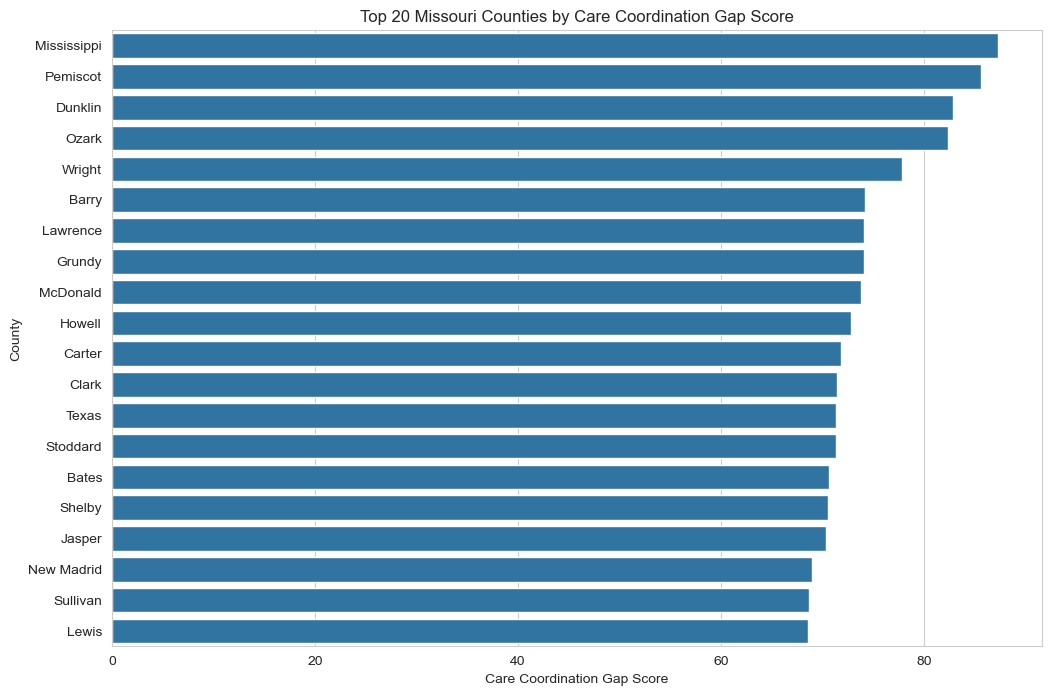

In [51]:
# Select top 20 highest-gap counties

top20 = county_project.head(20)

# Create horizontal bar chart
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20,
    y="county_name",
    x="care_coordination_gap_score"
)

# Chart labels
plt.title("Top 20 Missouri Counties by Care Coordination Gap Score")
plt.xlabel("Care Coordination Gap Score")
plt.ylabel("County")

# Show chart
plt.show()

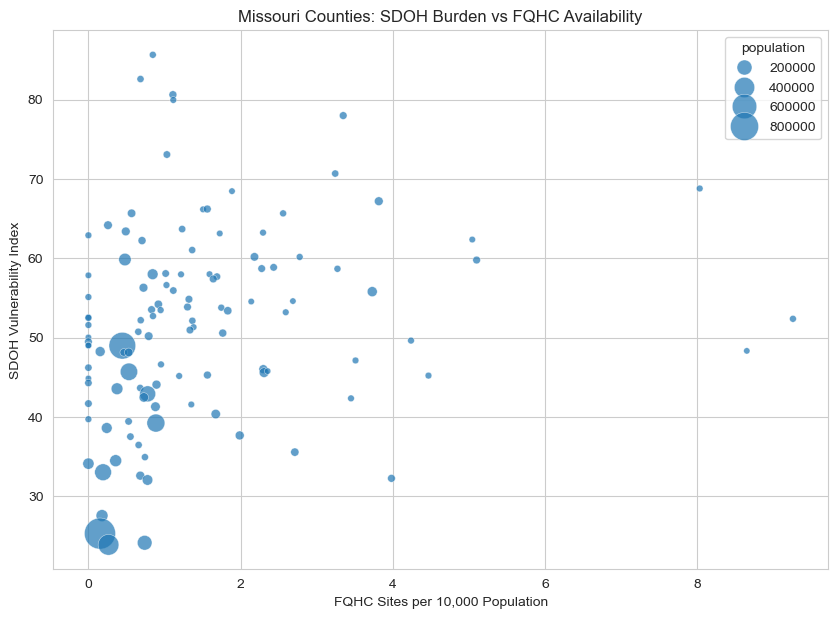

In [52]:
# Scatter plot of SDOH burden vs FQHC availability

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=county_project,
    x="fqhc_per_10000",
    y="sdoh_vulnerability_index",
    size="population",
    sizes=(20, 500),
    alpha=0.7
)

# Add labels
plt.title("Missouri Counties: SDOH Burden vs FQHC Availability")
plt.xlabel("FQHC Sites per 10,000 Population")
plt.ylabel("SDOH Vulnerability Index")

# Show plot
plt.show()

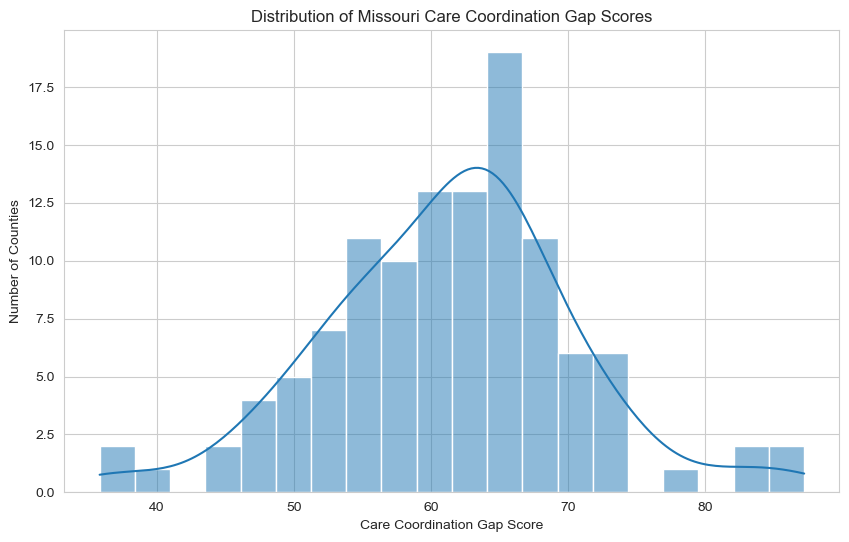

In [53]:
# Histogram of care coordination gap scores

plt.figure(figsize=(10, 6))

sns.histplot(
    county_project["care_coordination_gap_score"],
    bins=20,
    kde=True
)

# Labels
plt.title("Distribution of Missouri Care Coordination Gap Scores")
plt.xlabel("Care Coordination Gap Score")
plt.ylabel("Number of Counties")

# Show plot
plt.show()

In [55]:
# Select variables for correlation analysis

corr_vars = county_project[[
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate",
    "fqhc_per_10000",
    "sdoh_vulnerability_index",
    "care_coordination_gap_score"
]]

# Calculate correlations
corr_matrix = corr_vars.corr()

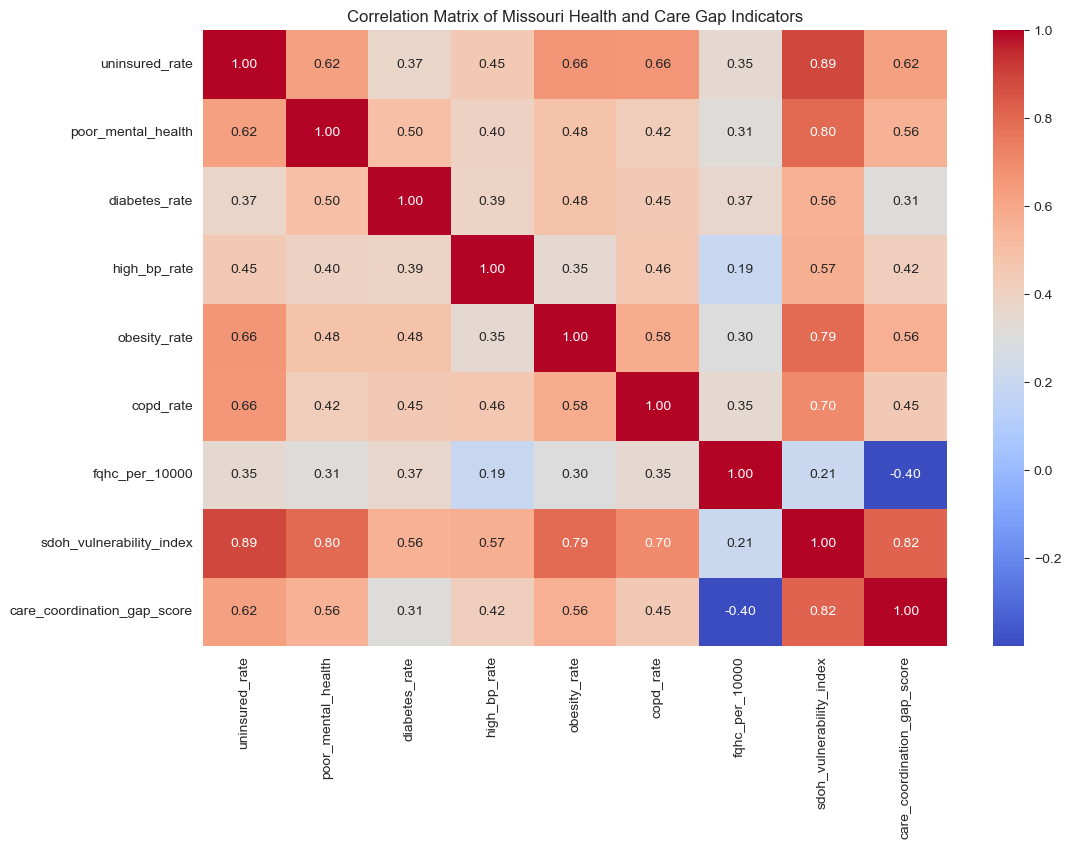

In [56]:
# Create correlation heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Chart title
plt.title("Correlation Matrix of Missouri Health and Care Gap Indicators")

# Show chart
plt.show()

In [57]:
# Create charts output folder

from pathlib import Path

charts_dir = Path("outputs/charts")
charts_dir.mkdir(parents=True, exist_ok=True)

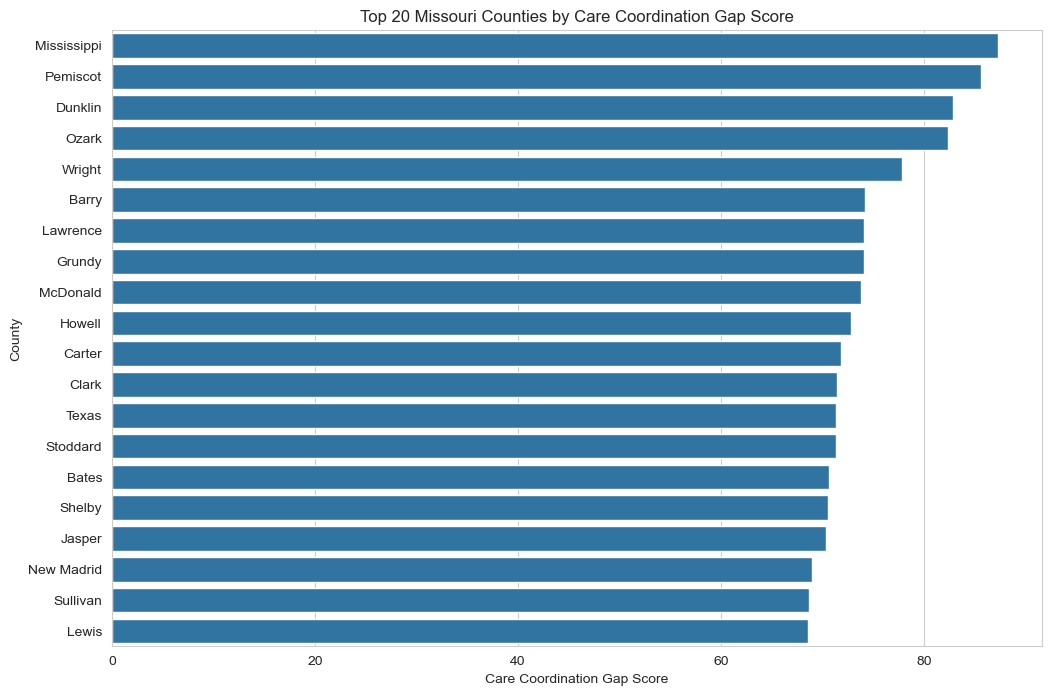

In [58]:
# Save top 20 counties chart

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20,
    y="county_name",
    x="care_coordination_gap_score"
)

plt.title("Top 20 Missouri Counties by Care Coordination Gap Score")
plt.xlabel("Care Coordination Gap Score")
plt.ylabel("County")

# Save figure
plt.savefig(
    "outputs/charts/top20_care_gap_counties.png",
    bbox_inches="tight"
)

plt.show()

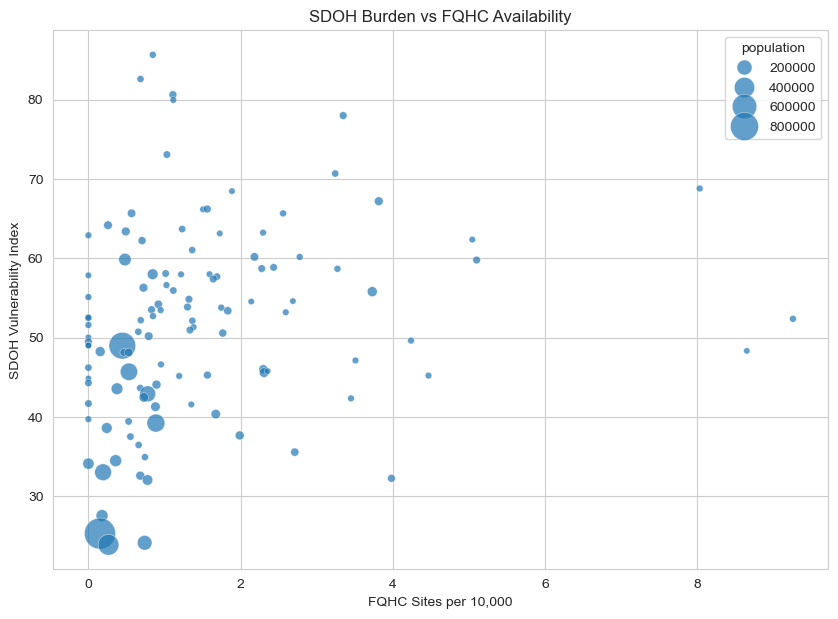

In [59]:
# Save scatter plot

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=county_project,
    x="fqhc_per_10000",
    y="sdoh_vulnerability_index",
    size="population",
    sizes=(20, 500),
    alpha=0.7
)

plt.title("SDOH Burden vs FQHC Availability")
plt.xlabel("FQHC Sites per 10,000")
plt.ylabel("SDOH Vulnerability Index")

# Save chart
plt.savefig(
    "outputs/charts/sdoh_vs_fqhc_scatter.png",
    bbox_inches="tight"
)

plt.show()

## Step 3 — Census ACS Poverty and Income Data

This section incorporates Census ACS socioeconomic indicators,
including poverty rate and median household income, to strengthen
the SDOH vulnerability model.

## Data Quality Correction Before Final Scoring

The initial care gap score was treated as a prototype because it used CDC PLACES health burden measures and HRSA FQHC supply, but did not yet include Census ACS poverty data. Since poverty is a core SDOH indicator in the project methodology, the final SDOH Vulnerability Index is recalculated after merging ACS county-level poverty and income data.

In [60]:
# Load Missouri county-level ACS poverty and income data from Census API
# B17001_001E = total poverty universe
# B17001_002E = population below poverty
# B19013_001E = median household income
# B01003_001E = total population

acs_url = (
    "https://api.census.gov/data/2023/acs/acs5"
    "?get=NAME,B17001_001E,B17001_002E,B19013_001E,B01003_001E"
    "&for=county:*"
    "&in=state:29"
)

acs = pd.read_json(acs_url)

# Use first row as column names
acs.columns = acs.iloc[0]

# Remove header row from data
acs = acs.iloc[1:].copy()

acs.head()

,NAME,B17001_001E,B17001_002E,B19013_001E,B01003_001E,state,county
1,"Adair County, Missouri",23287,4942,56583,25224,29,001
2,"Andrew County, Missouri",17831,1316,74007,18086,29,003
3,"Atchison County, Missouri",5114,639,59260,5216,29,005
4,"Audrain County, Missouri",23464,4231,56232,24688,29,007
5,"Barry County, Missouri",34286,5714,56611,34831,29,009


In [61]:
# Rename ACS columns into clear analytical names

acs = acs.rename(columns={
    "NAME": "county_full_name",
    "B17001_001E": "poverty_universe",
    "B17001_002E": "poverty_count",
    "B19013_001E": "median_household_income",
    "B01003_001E": "acs_population",
    "county": "county_code"
})

# Convert numeric columns from text to numbers
numeric_cols = [
    "poverty_universe",
    "poverty_count",
    "median_household_income",
    "acs_population"
]

for col in numeric_cols:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")

# Calculate poverty rate
acs["poverty_rate"] = (
    acs["poverty_count"] / acs["poverty_universe"]
) * 100

acs.head()

,county_full_name,poverty_universe,poverty_count,median_household_income,acs_population,state,county_code,poverty_rate
1,"Adair County, Missouri",23287,4942,56583,25224,29,001,21.222141
2,"Andrew County, Missouri",17831,1316,74007,18086,29,003,7.380405
3,"Atchison County, Missouri",5114,639,59260,5216,29,005,12.495111
4,"Audrain County, Missouri",23464,4231,56232,24688,29,007,18.031879
5,"Barry County, Missouri",34286,5714,56611,34831,29,009,16.665694


In [62]:
# Extract county name from ACS NAME column
# Example: "Adair County, Missouri" becomes "Adair"

acs["county_name"] = (
    acs["county_full_name"]
    .str.replace(" County, Missouri", "", regex=False)
    .str.replace(" city, Missouri", "", regex=False)
    .str.strip()
)

# Standardize St. Louis naming
acs["county_name"] = acs["county_name"].replace({
    "St. Louis": "Saint Louis",
    "St. Louis city": "Saint Louis City"
})

acs[["county_full_name", "county_name", "poverty_rate"]].head()

,county_full_name,county_name,poverty_rate
1,"Adair County, Missouri",Adair,21.222141
2,"Andrew County, Missouri",Andrew,7.380405
3,"Atchison County, Missouri",Atchison,12.495111
4,"Audrain County, Missouri",Audrain,18.031879
5,"Barry County, Missouri",Barry,16.665694


In [63]:
# Merge ACS poverty and income data into county_project

county_project = county_project.merge(
    acs[[
        "county_name",
        "poverty_rate",
        "median_household_income",
        "acs_population"
    ]],
    on="county_name",
    how="left"
)

# Check merge results
county_project[[
    "county_name",
    "population",
    "poverty_rate",
    "median_household_income"
]].head()

,county_name,population,poverty_rate,median_household_income
0,Mississippi,11822,23.022798,46258
1,Pemiscot,14613,27.355036,40748
2,Dunklin,27032,21.446569,47368
3,Ozark,8970,21.688132,42329
4,Wright,19403,17.551221,47304


In [64]:
# Identify counties where ACS data did not merge correctly

county_project[
    county_project["poverty_rate"].isna()
][["county_name", "population"]]

,county_name,population


In [65]:
# Convert poverty rate to numeric

county_project["poverty_rate"] = pd.to_numeric(
    county_project["poverty_rate"],
    errors="coerce"
)

# Normalize final SDOH indicators

county_project["uninsured_score"] = minmax_scale(county_project["uninsured_rate"])
county_project["poverty_score"] = minmax_scale(county_project["poverty_rate"])
county_project["mental_health_score"] = minmax_scale(county_project["poor_mental_health"])
county_project["chronic_disease_score"] = minmax_scale(
    county_project[[
        "diabetes_rate",
        "high_bp_rate",
        "obesity_rate",
        "copd_rate"
    ]].mean(axis=1)
)
county_project["fqhc_shortage_score"] = 100 - minmax_scale(
    county_project["fqhc_per_10000"]
)

# Final SDOH Vulnerability Index aligned with the project blueprint

county_project["sdoh_vulnerability_index"] = (
    0.25 * county_project["uninsured_score"] +
    0.25 * county_project["poverty_score"] +
    0.20 * county_project["chronic_disease_score"] +
    0.15 * county_project["mental_health_score"] +
    0.15 * county_project["fqhc_shortage_score"]
)

## Step 4 — SDOH Vulnerability and Care Coordination Gap Scoring

This section normalizes county-level indicators and combines them
into composite analytical scores representing SDOH vulnerability
and care coordination gaps across Missouri.

In [66]:
# Recalculate care coordination gap score using final SDOH index
# Higher score = higher need and lower care coordination supply

county_project["resource_gap_score"] = county_project["fqhc_shortage_score"]

county_project["care_coordination_gap_score"] = (
    0.70 * county_project["sdoh_vulnerability_index"] +
    0.30 * county_project["resource_gap_score"]
)

# Re-rank counties
county_project["care_gap_rank"] = (
    county_project["care_coordination_gap_score"]
    .rank(ascending=False, method="dense")
)

# Sort by highest gap
county_project = county_project.sort_values(
    "care_coordination_gap_score",
    ascending=False
)

county_project[[
    "county_name",
    "population",
    "poverty_rate",
    "uninsured_rate",
    "poor_mental_health",
    "fqhc_sites",
    "fqhc_per_10000",
    "sdoh_vulnerability_index",
    "care_coordination_gap_score",
    "care_gap_rank"
]].head(20)

,county_name,population,poverty_rate,uninsured_rate,poor_mental_health,fqhc_sites,fqhc_per_10000,sdoh_vulnerability_index,care_coordination_gap_score,care_gap_rank
1,Pemiscot,14613,27.355036,13.1,20.5,1.0,0.684322,92.476641,92.515213,1.0
0,Mississippi,11822,23.022798,13.2,21.2,1.0,0.845881,88.265297,89.043532,2.0
3,Ozark,8970,21.688132,12.4,22.0,1.0,1.114827,86.096946,86.653815,3.0
2,Dunklin,27032,21.446569,12.9,20.0,3.0,1.109796,82.854315,84.400284,4.0
9,Howell,40735,21.388868,10.8,21.0,2.0,0.490978,72.419070,79.101696,5.0
4,Wright,19403,17.551221,12.1,21.6,2.0,1.030768,72.196343,77.195895,6.0
7,Grundy,9815,16.835017,10.7,20.4,0.0,0.000000,65.546857,75.882800,7.0
6,Lawrence,38872,16.533376,11.6,19.0,1.0,0.257255,66.431218,75.667885,8.0
5,Barry,35265,16.665694,12.8,20.1,2.0,0.567135,67.493773,75.407105,9.0
12,Texas,25619,19.337557,11.8,19.1,4.0,1.561341,71.306739,74.853161,10.0


### Interpretation

Several of the highest-ranked counties are located in southeastern
and rural Missouri, where elevated poverty burden, poor mental health,
and chronic disease prevalence coincide with relatively limited
care coordination infrastructure.

These counties may represent priority regions for population health
interventions, SDOH-focused outreach, and expanded post-discharge
care coordination programs.

## Updated Visualizations After ACS Integration

The following visualizations were regenerated after incorporating
Census ACS poverty and income data into the final SDOH Vulnerability
Index and Care Coordination Gap Score calculations.

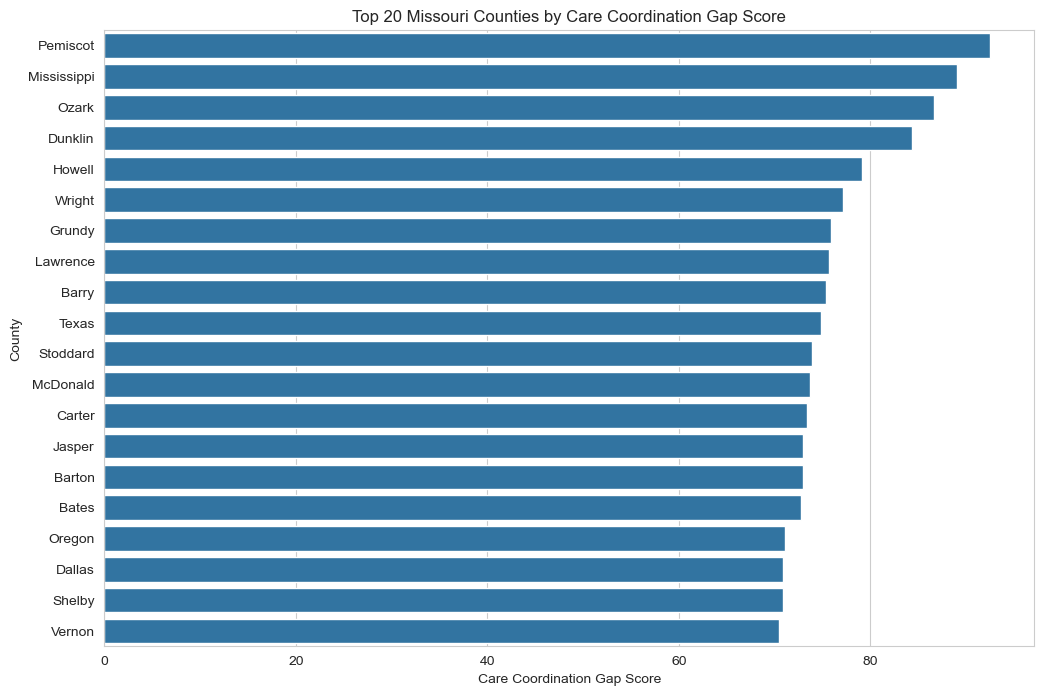

In [68]:
# Select updated top 20 counties after ACS integration

top20 = county_project.head(20)

# Create updated horizontal bar chart

plt.figure(figsize=(12, 8))

sns.barplot(
    data=top20,
    y="county_name",
    x="care_coordination_gap_score"
)

# Add chart labels
plt.title("Top 20 Missouri Counties by Care Coordination Gap Score")
plt.xlabel("Care Coordination Gap Score")
plt.ylabel("County")

# Save updated chart
plt.savefig(
    "outputs/charts/top20_care_gap_updated.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

Following ACS poverty integration, southeastern and rural Missouri
counties continue to dominate the highest care coordination gap rankings.
This suggests that socioeconomic burden remains strongly associated
with elevated chronic disease prevalence and reduced healthcare resource availability.

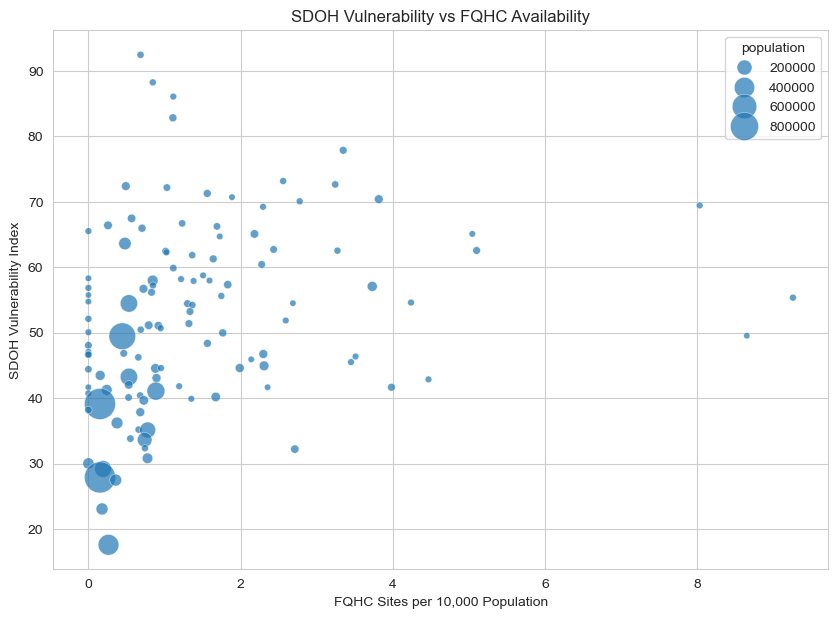

In [69]:
# Updated scatter plot using final analytical scores

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=county_project,
    x="fqhc_per_10000",
    y="sdoh_vulnerability_index",
    size="population",
    sizes=(20, 500),
    alpha=0.7
)

# Add labels
plt.title("SDOH Vulnerability vs FQHC Availability")
plt.xlabel("FQHC Sites per 10,000 Population")
plt.ylabel("SDOH Vulnerability Index")

# Save chart
plt.savefig(
    "outputs/charts/final_sdoh_vs_fqhc_scatter.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

Most Missouri counties demonstrate relatively low FQHC density,
with many clustering below 2 FQHC sites per 10,000 population.

Several counties exhibit elevated SDOH vulnerability despite
limited healthcare resource availability, suggesting potential
mismatches between healthcare need and care coordination capacity.

Larger population counties also appear concentrated in lower
FQHC-density regions, which may increase operational pressure
on existing safety-net infrastructure.

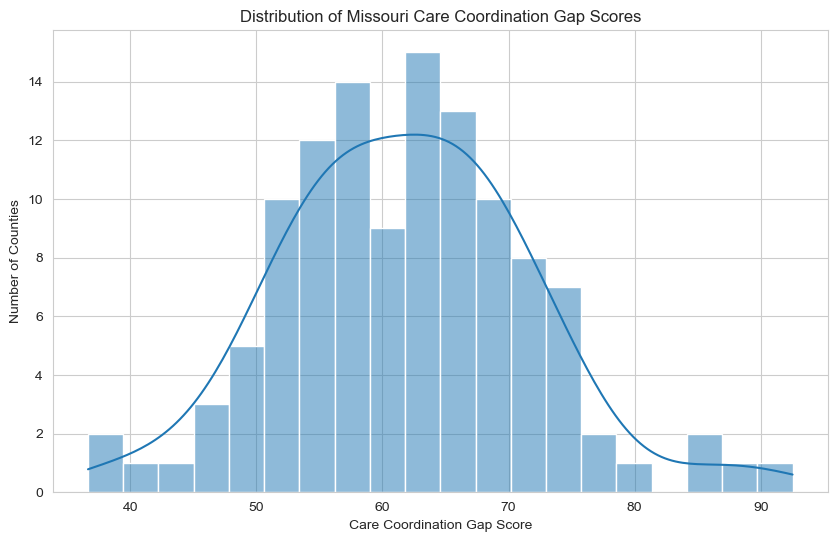

In [70]:
# Distribution of final care coordination gap scores

plt.figure(figsize=(10, 6))

sns.histplot(
    county_project["care_coordination_gap_score"],
    bins=20,
    kde=True
)

# Labels
plt.title("Distribution of Missouri Care Coordination Gap Scores")
plt.xlabel("Care Coordination Gap Score")
plt.ylabel("Number of Counties")

# Save chart
plt.savefig(
    "outputs/charts/final_gap_distribution.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

The distribution of care coordination gap scores demonstrates
moderate variation across Missouri counties, with most counties
clustered around the middle range of the distribution.

A smaller number of counties exhibit substantially elevated scores,
indicating potential high-priority regions where social vulnerability,
disease burden, and healthcare resource limitations may converge.

In [71]:
# Select final analytical variables for correlation analysis

corr_vars = county_project[[
    "poverty_rate",
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate",
    "fqhc_per_10000",
    "sdoh_vulnerability_index",
    "care_coordination_gap_score"
]]

# Calculate correlation matrix
corr_matrix = corr_vars.corr()

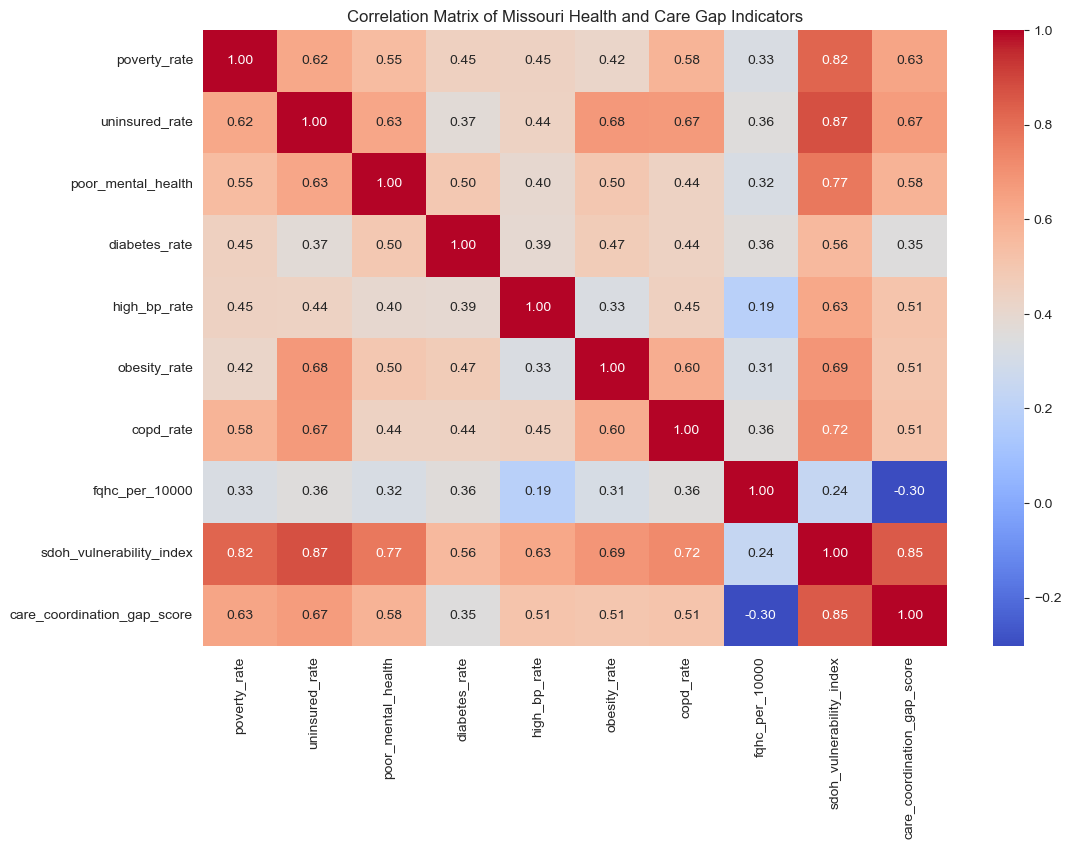

In [72]:
# Create updated heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

# Add title
plt.title("Correlation Matrix of Missouri Health and Care Gap Indicators")

# Save chart
plt.savefig(
    "outputs/charts/final_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

### Interpretation

The correlation matrix demonstrates several expected relationships
between socioeconomic burden, chronic disease prevalence, and
care coordination gap severity.

Poverty and uninsured burden demonstrate strong positive associations
with the SDOH Vulnerability Index, supporting the internal consistency
of the scoring framework.

FQHC availability demonstrates a modest inverse relationship with
care coordination gap severity, suggesting that increased healthcare
resource availability may partially mitigate population-level care gaps.

In [73]:
# Create rounded presentation-ready columns

county_project["sdoh_vulnerability_index"] = (
    county_project["sdoh_vulnerability_index"]
    .round(2)
)

county_project["care_coordination_gap_score"] = (
    county_project["care_coordination_gap_score"]
    .round(2)
)

county_project["fqhc_per_10000"] = (
    county_project["fqhc_per_10000"]
    .round(2)
)

In [74]:
# Save updated finalized analytical dataset

county_project.to_csv(
    "data/processed/missouri_county_final_analytical_dataset.csv",
    index=False
)

print("Final analytical dataset updated and saved.")

Final analytical dataset updated and saved.


In [75]:
# Verify file extension

import os

os.listdir("data/processed")

['.ipynb_checkpoints',
 'missouri_county_care_gap_analysis.csv',
 'missouri_county_final_analytical_dataset.csv',
 'missouri_county_health_metrics.csv',
 'missouri_county_project1_base.csv',
 'missouri_county_sdoh_vulnerability_index.csv']

In [76]:
# Save a true Excel version of the dataset

county_project.to_excel(
    "data/processed/missouri_county_final_analytical_dataset.xlsx",
    index=False
)

print("Excel version saved successfully.")

Excel version saved successfully.


# Step 6 — Missouri County Choropleth Mapping

This section integrates geographic county boundary data with the
final analytical dataset to visualize spatial patterns of SDOH
vulnerability and care coordination gaps across Missouri.

Choropleth mapping helps identify geographic clusters of elevated
population health burden and limited healthcare resource availability.

In [79]:
# Import geospatial mapping libraries

import geopandas as gpd
import matplotlib.pyplot as plt

In [80]:
# Load Census TIGER/Line county shapefile
# This dataset contains county boundary polygons for the United States

county_shapes_url = (
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/"
    "cb_2023_us_county_500k.zip"
)

counties_geo = gpd.read_file(county_shapes_url)

# Preview shapefile data
counties_geo.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
0,01,003,00161527,0500000US01003,01003,Baldwin,Baldwin County,AL,Alabama,06,4117725048,1132887203,"POLYGON ((-88.02858 30.22676, -88.02399 30.230..."
1,01,069,00161560,0500000US01069,01069,Houston,Houston County,AL,Alabama,06,1501742235,4795415,"POLYGON ((-85.71209 31.19727, -85.70934 31.198..."
2,01,005,00161528,0500000US01005,01005,Barbour,Barbour County,AL,Alabama,06,2292160151,50523213,"POLYGON ((-85.74803 31.61918, -85.74544 31.618..."
3,01,119,00161585,0500000US01119,01119,Sumter,Sumter County,AL,Alabama,06,2340898915,24634880,"POLYGON ((-88.41492 32.36452, -88.41471 32.366..."
4,05,091,00069166,0500000US05091,05091,Miller,Miller County,AR,Arkansas,06,1616257232,36848741,"POLYGON ((-94.04343 33.55158, -94.04332 33.552..."


### Geographic Boundary Data

The Census TIGER/Line shapefile provides polygon boundaries for
all U.S. counties. These geographic boundaries will be merged
with the analytical dataset using county FIPS codes.

In [81]:
# Filter geographic boundaries to Missouri counties only
# Missouri FIPS code = 29

mo_geo = counties_geo[
    counties_geo["STATEFP"] == "29"
].copy()

# Check Missouri county boundaries
mo_geo.head()

,STATEFP,COUNTYFP,COUNTYNS,GEOIDFQ,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER,geometry
70,29,113,00758511,0500000US29113,29113,Lincoln,Lincoln County,MO,Missouri,06,1622789067,36002285,"POLYGON ((-91.26382 39.00761, -91.26311 39.037..."
204,29,041,00758475,0500000US29041,29041,Chariton,Chariton County,MO,Missouri,06,1945541994,40353307,"POLYGON ((-93.28745 39.6833, -93.28613 39.6838..."
205,29,065,00758487,0500000US29065,29065,Dent,Dent County,MO,Missouri,06,1949641179,4518781,"POLYGON ((-91.80837 37.67827, -91.80819 37.702..."
459,29,143,00758526,0500000US29143,29143,New Madrid,New Madrid County,MO,Missouri,06,1747940899,56236293,"POLYGON ((-89.97129 36.39314, -89.97032 36.397..."
460,29,031,00758470,0500000US29031,29031,Cape Girardeau,Cape Girardeau County,MO,Missouri,06,1498351218,20284964,"POLYGON ((-89.8668 37.21898, -89.86326 37.2190..."


In [82]:
# Standardize county FIPS codes in both datasets
# FIPS codes must match exactly for geographic merging

mo_geo["county_fips"] = (
    mo_geo["GEOID"]
    .astype(str)
)

county_project["county_fips"] = (
    county_project["county_fips"]
    .astype(str)
    .str.zfill(5)
)

# Verify formatting
county_project["county_fips"].head()

1    29155
0    29133
3    29153
2    29069
9    29091
Name: county_fips, dtype: object

### County FIPS Standardization

County-level datasets frequently use FIPS codes as geographic identifiers.
Both datasets are standardized to five-digit county FIPS codes to ensure
accurate geographic merging.

In [83]:
# Merge Missouri geographic boundaries with analytical dataset

mo_map = mo_geo.merge(
    county_project,
    on="county_fips",
    how="left"
)

# Preview merged mapping dataset
mo_map[[
    "NAME",
    "county_name",
    "sdoh_vulnerability_index",
    "care_coordination_gap_score"
]].head()

,NAME,county_name,sdoh_vulnerability_index,care_coordination_gap_score
0,Lincoln,Lincoln,43.51,59.95
1,Chariton,Chariton,39.93,53.57
2,Dent,Dent,54.26,63.55
3,New Madrid,New Madrid,72.68,70.37
4,Cape Girardeau,Cape Girardeau,41.29,58.12


In [84]:
# Identify counties with missing analytical data after merge

missing_counties = mo_map[
    mo_map["care_coordination_gap_score"].isna()
]

# Display missing counties if any exist
missing_counties[[
    "NAME",
    "county_fips"
]]

,NAME,county_fips


### Merge Validation

This validation step checks whether any Missouri counties failed
to merge correctly between the geographic boundary dataset and
the analytical dataset.

Ideally, all counties should merge successfully.

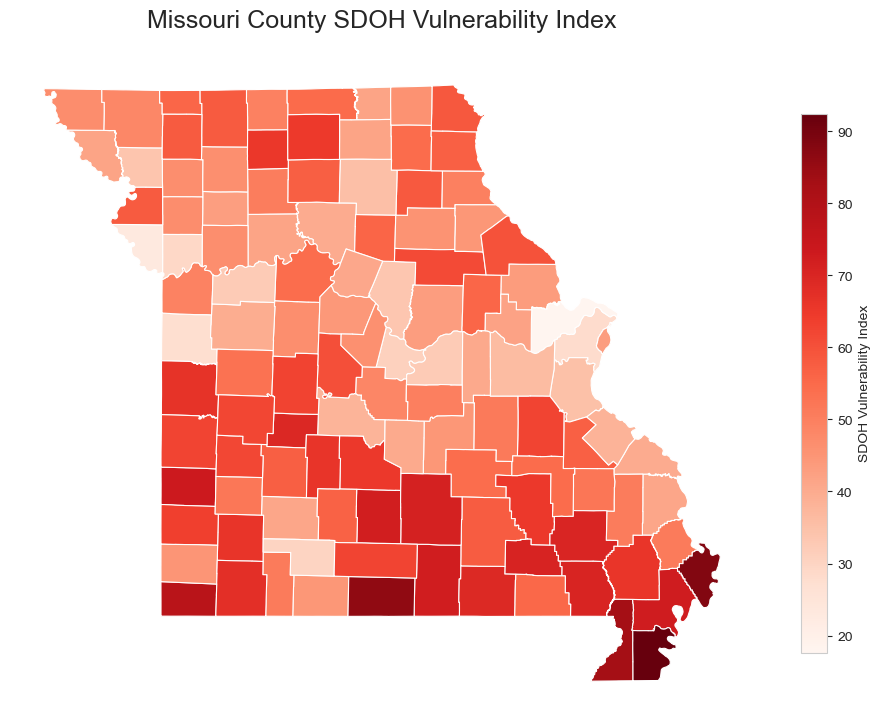

In [86]:
# Create improved professional choropleth map

fig, ax = plt.subplots(figsize=(12, 10))

mo_map.plot(
    column="sdoh_vulnerability_index",
    cmap="Reds",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "SDOH Vulnerability Index",
        "shrink": 0.7
    },
    ax=ax
)

# Improve title formatting
ax.set_title(
    "Missouri County SDOH Vulnerability Index",
    fontsize=18,
    pad=20
)

# Remove axes
ax.axis("off")

# Remove gray background
fig.patch.set_facecolor("white")

# Save high-quality figure
plt.savefig(
    "outputs/charts/missouri_sdoh_vulnerability_map_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Display map
plt.show()

### Interpretation

The SDOH Vulnerability Index map demonstrates substantial geographic
variation across Missouri counties.

Several southeastern and southern rural counties demonstrate the
highest vulnerability scores, reflecting elevated poverty burden,
chronic disease prevalence, uninsured burden, and limited healthcare
resource availability.

The geographic clustering observed in these regions suggests that
health burden may not be randomly distributed across the state,
but instead concentrated within specific regional socioeconomic
and healthcare access patterns.

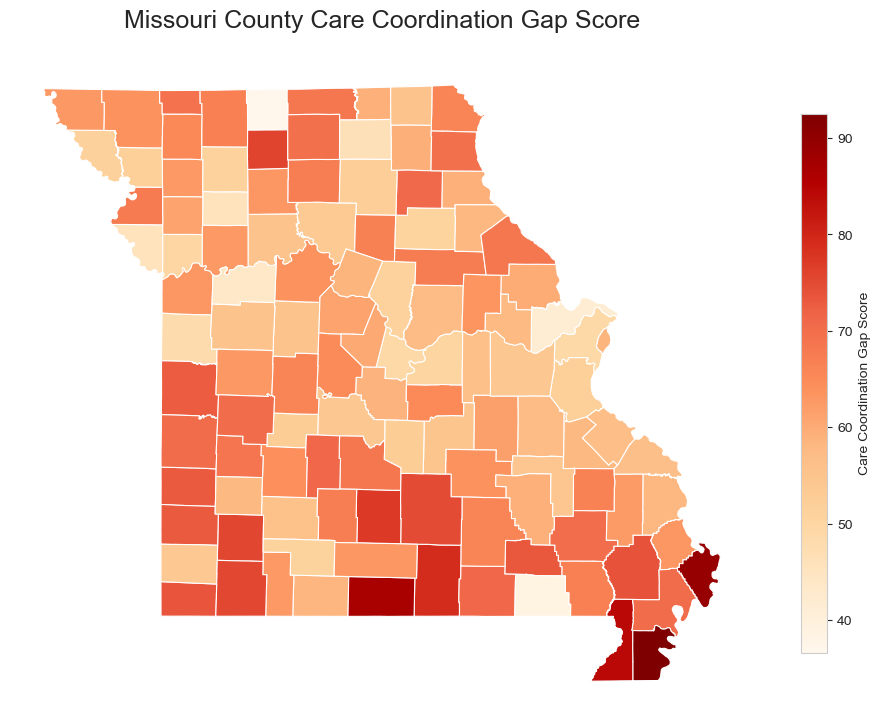

In [87]:
# Create professional care coordination gap map

fig, ax = plt.subplots(figsize=(12, 10))

mo_map.plot(
    column="care_coordination_gap_score",
    cmap="OrRd",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "label": "Care Coordination Gap Score",
        "shrink": 0.7
    },
    ax=ax
)

# Add map title
ax.set_title(
    "Missouri County Care Coordination Gap Score",
    fontsize=18,
    pad=20
)

# Remove axes
ax.axis("off")

# White background
fig.patch.set_facecolor("white")

# Save figure
plt.savefig(
    "outputs/charts/missouri_care_gap_map_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Display map
plt.show()

### Interpretation

The Care Coordination Gap Score map identifies counties where
high population health burden overlaps with limited healthcare
resource availability.

Several southeastern Missouri counties demonstrate especially
elevated care gap scores, suggesting potential priority regions
for population health intervention, post-discharge coordination,
and SDOH-focused care management expansion.

# Step 7 — County Risk Tier Classification

This section categorizes Missouri counties into operational risk tiers
based on the Care Coordination Gap Score.

Risk tiering simplifies interpretation of continuous analytical scores
and supports prioritization of counties for intervention, outreach,
and resource allocation planning.

In [88]:
# Review distribution statistics for care coordination gap score

county_project["care_coordination_gap_score"].describe()

count    117.000000
mean      61.906154
std        9.946751
min       36.660000
25%       55.290000
50%       62.670000
75%       68.310000
max       92.520000
Name: care_coordination_gap_score, dtype: float64

### Interpretation

The care coordination gap score demonstrates meaningful variability
across Missouri counties, with scores ranging from approximately
37 to 93.

Most counties cluster within the moderate-to-high burden range,
while several counties exhibit substantially elevated scores,
suggesting concentrated regions of increased healthcare vulnerability
and resource limitation.

The distribution supports the analytical usefulness of the scoring
framework for identifying county-level differences in population
health burden and care coordination need.

In [89]:
# Create county risk tiers using quartiles

county_project["risk_tier"] = pd.qcut(
    county_project["care_coordination_gap_score"],
    q=4,
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Critical Risk"
    ]
)

In [90]:
# Count counties within each risk category

county_project["risk_tier"].value_counts()

risk_tier
Low Risk         30
Moderate Risk    29
High Risk        29
Critical Risk    29
Name: count, dtype: int64

In [91]:
# Display highest-risk counties

county_project[[
    "county_name",
    "care_coordination_gap_score",
    "risk_tier"
]].sort_values(
    "care_coordination_gap_score",
    ascending=False
).head(25)

,county_name,care_coordination_gap_score,risk_tier
1,Pemiscot,92.52,Critical Risk
0,Mississippi,89.04,Critical Risk
3,Ozark,86.65,Critical Risk
2,Dunklin,84.40,Critical Risk
9,Howell,79.10,Critical Risk
4,Wright,77.20,Critical Risk
7,Grundy,75.88,Critical Risk
6,Lawrence,75.67,Critical Risk
5,Barry,75.41,Critical Risk
12,Texas,74.85,Critical Risk


### Interpretation

Several southeastern and rural Missouri counties were classified
within the Critical Risk category, indicating elevated combined
burden across socioeconomic vulnerability, chronic disease prevalence,
mental health burden, uninsured burden, and healthcare resource shortage.

The consistency of these counties across multiple analytical outputs
supports the stability and internal coherence of the scoring framework.

In [92]:
# Create numeric risk tier codes for dashboard filtering

risk_mapping = {
    "Low Risk": 1,
    "Moderate Risk": 2,
    "High Risk": 3,
    "Critical Risk": 4
}

county_project["risk_tier_code"] = (
    county_project["risk_tier"]
    .map(risk_mapping)
)

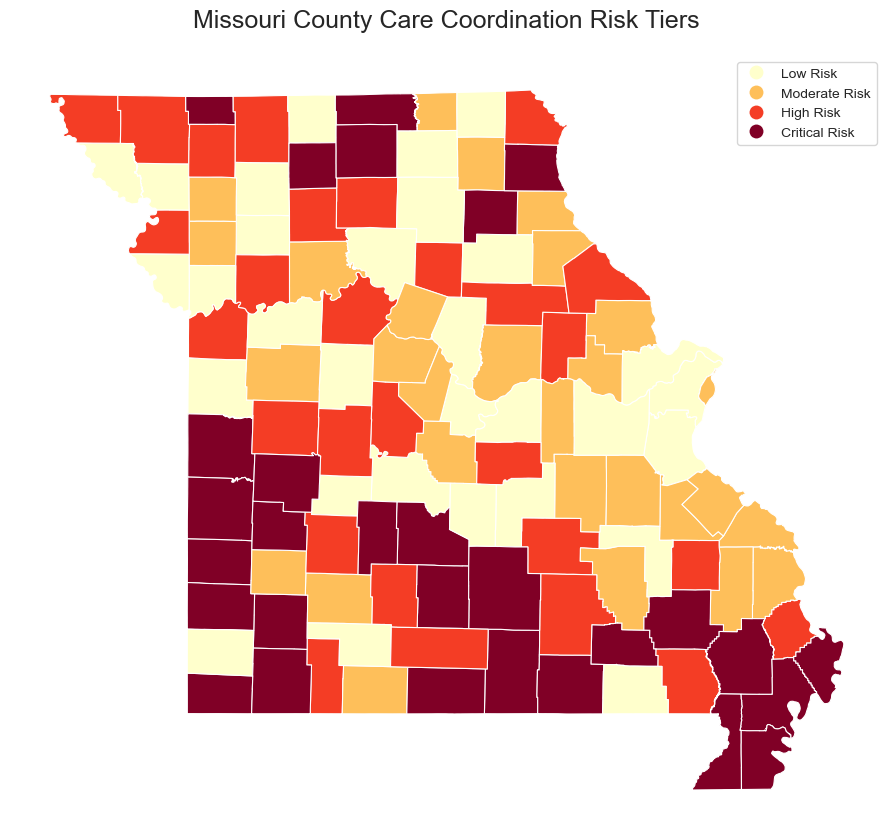

In [94]:
# Create improved categorical risk-tier map

fig, ax = plt.subplots(figsize=(12, 10))

# Plot categorical tiers
mo_map.plot(
    column="risk_tier",
    cmap="YlOrRd",
    linewidth=0.8,
    edgecolor="white",
    legend=True,
    categorical=True,
    ax=ax
)

# Add title
ax.set_title(
    "Missouri County Care Coordination Risk Tiers",
    fontsize=18,
    pad=20
)

# Remove axes
ax.axis("off")

# White background
fig.patch.set_facecolor("white")

# Save improved map
plt.savefig(
    "outputs/charts/missouri_risk_tier_map_final.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

# Show map
plt.show()

### Interpretation

The county risk-tier map demonstrates clear geographic clustering
of elevated care coordination burden across several southern and
southeastern Missouri counties.

The visual distribution suggests that healthcare vulnerability
may be regionally concentrated rather than uniformly distributed,
supporting the potential value of geographically targeted population
health and care coordination interventions.

In [95]:
# Save enhanced analytical dataset with risk tiers

county_project.to_csv(
    "data/processed/missouri_county_final_dashboard_dataset.csv",
    index=False
)

county_project.to_excel(
    "data/processed/missouri_county_final_dashboard_dataset.xlsx",
    index=False
)

print("Final dashboard datasets saved successfully.")

Final dashboard datasets saved successfully.
